## **Business understanding**

Goal:

 predict wine quality (0-10 sensory score) from its physicochemical properties. Useful framing: if a producer knows which chemical properties drive perceived quality, they can adjust their process.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

df.info()     # data types, how many rows, missing values
df.describe()  # summary statistics for numerical columns
df.isnull().sum()  # count of missing values per column 

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

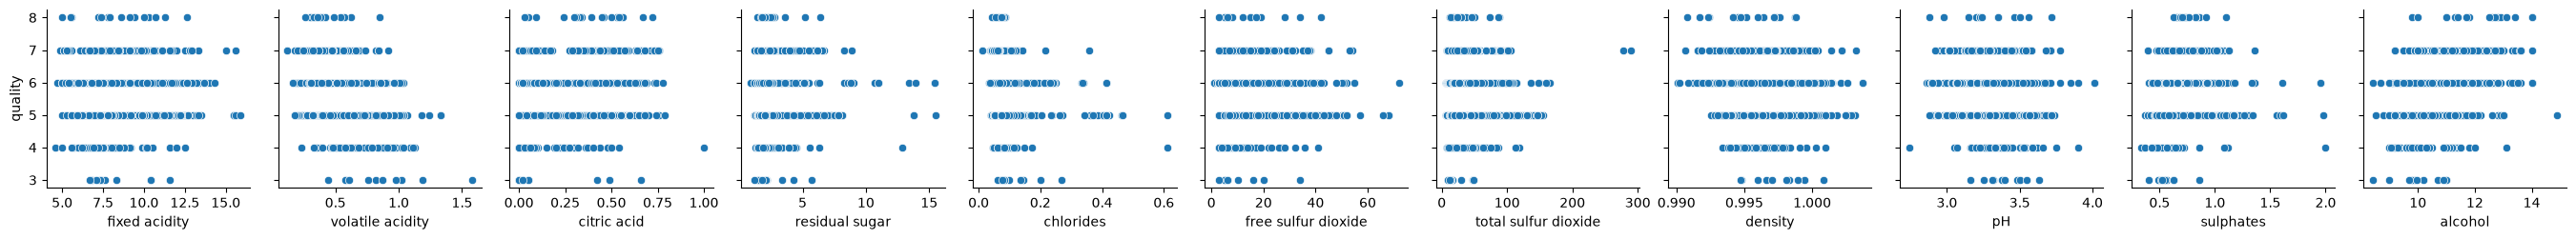

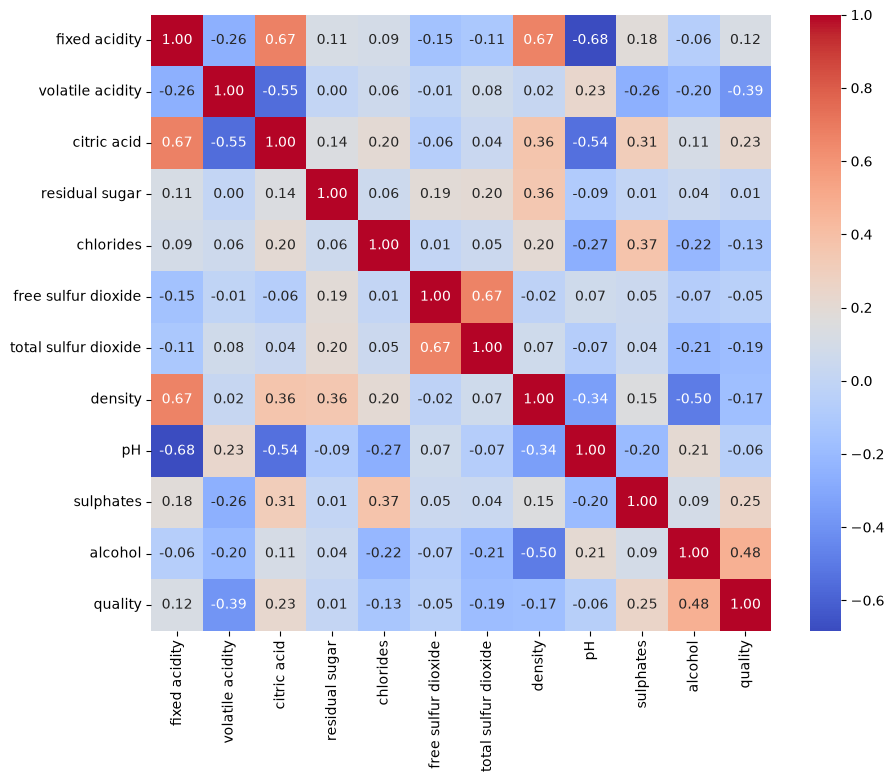

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [4]:
sns.pairplot(df, y_vars='quality', x_vars=df.columns[:-1], height=2.5)
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

print(df.corr()['quality'].sort_values(ascending=False))

## **Data understanding**

## **Data preparation**

In [5]:
X = df.drop('quality', axis=1)
y = df['quality']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Modelling**

Linear regression rests on a few promises. Think of them like ground rules for a game , if the data breaks the rules, your model's outputs (coefficients, p-values, predictions) can't be trusted even if the R² looks nice.

a) Linearity = does each predictor have a roughly straight-line relationship with the target? Check via the pairplot above, or residual-vs-fitted after a first fit (see below).

b) Multicollinearity = are predictors independent of each other? Ridge regression's whole reason for existing is to handle this, so let's quantify it with Variance Inflation Factor (VIF). VIF > 5-10 on a feature = trouble.

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_const = add_constant(X_train)
vif = pd.DataFrame()
vif['feature'] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif)

                 feature       VIF
0                  const  1.000000
1          fixed acidity  7.374554
2       volatile acidity  1.813146
3            citric acid  3.211154
4         residual sugar  1.731605
5              chlorides  1.519827
6    free sulfur dioxide  1.982913
7   total sulfur dioxide  2.203259
8                density  6.016488
9                     pH  3.275199
10             sulphates  1.455527
11               alcohol  2.933465


c) constant variance of errors 

d) Normality of residuals = fit a first plain OLS model, then look at the residuals:

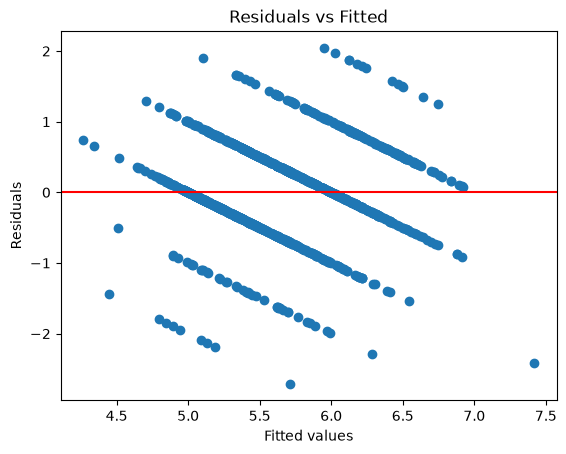

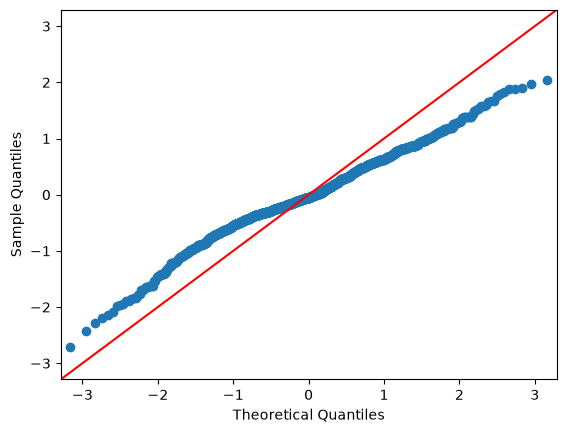

In [7]:
import statsmodels.api as sm

model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
residuals = model.resid
fitted = model.fittedvalues

# Homoscedasticity check
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel('Fitted values'); plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

# Normality check
sm.qqplot(residuals, line='45')
plt.show()

e) Independence of errors = Durbin-Watson stat, printed automatically at the bottom of model.summary() (close to 2 = good, far from 2 = autocorrelated errors).

In [8]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     61.48
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          1.48e-109
Time:                        21:26:13   Log-Likelihood:                -1266.4
No. Observations:                1279   AIC:                             2557.
Df Residuals:                    1267   BIC:                             2619.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   14.3551 

#### **The remedy**

- Wine quality data typically shows: (1) some multicollinearity among the acidity/sulfur-related features, and (2) features on very different scales (total sulfur dioxide is in the hundreds, chlorides is a small decimal). Both problems point to the same fix:

- Standardize the features (mean 0, std 1) = this alone helps numerical stability and puts coefficients on a comparable footing.
- Ridge regression (L2) = it doesn't remove multicollinearity, but it shrinks correlated coefficients toward each other and stabilizes them, trading a little bias for a lot less variance

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Plain linear regression (baseline)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Ridge with cross-validated alpha
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
ridge.fit(X_train_scaled, y_train)
print("Best alpha:", ridge.alpha_)

Best alpha: 79.06043210907701


## **Evaluation**

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

for name, m in [('Linear', lr), ('Ridge', ridge)]:
    preds = m.predict(X_test_scaled)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} -> MSE: {mse:.3f}, R²: {r2:.3f}")

Linear -> MSE: 0.390, R²: 0.403
Ridge -> MSE: 0.392, R²: 0.400


- R² tells you the proportion of variance in quality that your model explains, relative to just guessing the average every time. It's scale-free and easy to compare across problems — 0.6 means "explains 60% of the variation," regardless of whether quality was measured in points or percent.